In [1]:
import os
import sys
import h5py
import numpy as np
import pandas as pd
import scipy.sparse as sps
from scipy import sparse
import scipy as sp
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
# from nilearn import image, surface, plotting, datasets
from tqdm import tqdm
from matplotlib import font_manager
font_manager.fontManager.addfont("/n02dat01/users/lchai/anaconda3/envs/Nm/lib/python3.8/site-packages/matplotlib/mpl-data/fonts/ttf/arial.ttf")
plt.rcParams["font.sans-serif"] = "Arial" 

import warnings
warnings.filterwarnings('ignore')

<frozen importlib._bootstrap>:219: RuntimeWarning: scipy._lib.messagestream.MessageStream size changed, may indicate binary incompatibility. Expected 56 from C header, got 64 from PyObject


In [2]:
# remove the medial wall
dirc_L = '/n02dat01/users/dyli/Atlas/metric_index_L.txt'
select_ind_L = np.loadtxt( dirc_L ).astype(int)
dirc_R = '/n02dat01/users/dyli/Atlas/metric_index_R.txt'
select_ind_R = np.loadtxt( dirc_R ).astype(int)

_ = np.array([0, 2, 12, 14, 16, 18, 20, 22, 24, 26, 29, 31, 33, 35, 37, 39, 41, 43, 46, 48, 50, 52, 54, 56, 58, 60, 62, 64, 66, 68, 70, 4, 5, 6, 7, 8, 9, 10, 11, 28, 45])
# read the fiber name
l_idx = [1,3,13,15,17,19,25,27,30,32,36,38,40,42,44,47,49,51,53,55,57,59,61,63,65,67,69,71]
r_idx = [2,4,14,16,18,24,26,28,31,35,37,39,41,43,45,48,50,52,54,56,58,60,62,64,66,68,70,72]
m_idx = [4,5,6,7,8,9,10,11]
l_idx = np.array(l_idx)
r_idx = np.array(r_idx)
m_idx = np.array(m_idx)
l_idx = l_idx-1
r_idx = r_idx-1
label_f = open('/n02dat01/users/dyli/Grad_data/support_data/fiber_name_ori_nonum_nohemi.txt', 'r')
label_name = label_f.readlines()
label_name = [' '.join([i.strip() for i in price.strip().split('\n')]) for price in label_name]
label_name_lm = [label_name[l_idx[i]] for i in range(len(l_idx))] + [label_name[m_idx[i]] for i in range(len(m_idx))]
print(f'the number of fiber: {len(label_name_lm)}')

new_fiber_idx = []
for fi,ff in enumerate(_):
    if ff in list(l_idx)+list(m_idx): new_fiber_idx.append(fi)
new_fiber_idx = np.array(new_fiber_idx)
print(new_fiber_idx.shape)

print(len(l_idx), len(m_idx))

the number of fiber: 36
(36,)
28 8


# different number of modes: HCP

In [5]:
# read the sublist
list_path = '/n02dat01/users/dyli/Grad_data/support_data/HCP_U100_list.txt'
with open( list_path, 'r' ) as f:
    namelist = [ str( line.strip()) for line in f.readlines() ]
print(f'the sub num is {len(namelist)}')

# read the group MODE
x = np.loadtxt(f'/n01dat01/dyli/multi/support_code/BrainEigenmodes/data/template_eigenmodes/fsLR_32k_white-lh_emode_200.txt') # (32492, 200)
x = x[select_ind_L,:]

# train a GLM for each sub
# corr_re = np.zeros((len(namelist), len(list(np.arange(5,205,5))),36))
corr_re = np.zeros((len(namelist), len([1,2,3,4,5,6,7,8,9,10,15,20,25,30,35,40,45,50,60,70,80,90,100,110,120,130,140,150,160,170,180,190,200]),36))
for sub_i, sub in tqdm(enumerate(namelist)):
    # read the fingerprint
    if os.path.exists(f'/n04dat01/atlas_group/lma/HCP_S1200_individual_MSM_atlas/{sub}/{sub}_L_probtrackx_omatrix2/finger_print_fiber_MSMALL.npz'):
        _ = sps.load_npz(f'/n04dat01/atlas_group/lma/HCP_S1200_individual_MSM_atlas/{sub}/{sub}_L_probtrackx_omatrix2/finger_print_fiber_MSMALL.npz')
    else:
        _ = sps.load_npz(f'/n04dat01/atlas_group/lma/HCP_S1200_individual_MSM_atlas/{sub}/{sub}_L_probtrackx_omatrix2/finger_print_fiber.npz')
    _ = _.toarray()

    # check the all-zero row
    for ii in range(_.shape[0]):
        if len(np.unique(_[ii,:])) == 1: _[ii,:]=_[ii-1,:]
    for ii in range(_.shape[0]):
        if len(np.unique(_[ii,:])) == 1: sys.exit()

    # normalization
    fingerprint = np.array([_[:,i]/np.sum(_, axis=1) for i in range(_.shape[1])]).T

    # choose the left fibers and the cc fibers
    fingerprint = fingerprint[:, np.array(list(l_idx) + list(m_idx))]
    assert fingerprint.shape[0]==29696 and fingerprint.shape[1]==int(len(l_idx)+len(m_idx))

    # thr
    fingerprint[fingerprint<0.05] =0

    for ff in range(36):
        # read the parameter
        para = np.load(f'/n01dat01/dyli/multi/HCP_1200/{sub}/FP_{sub}_predict_by_200_group_whitemode_deve-mode_thr05_para_L.npy')[:, new_fiber_idx] # (200, 36)
        # for mode_i, mode_num in enumerate(list(np.arange(5,205,5))):
        for mode_i, mode_num in enumerate([1,2,3,4,5,6,7,8,9,10,15,20,25,30,35,40,45,50,60,70,80,90,100,110,120,130,140,150,160,170,180,190,200]):
            result = para[0:mode_num, ff]
            corr_re[sub_i,mode_i,ff] = np.corrcoef(np.squeeze(fingerprint[:,ff]), np.squeeze(np.dot(x[:, 0:mode_num],result.T)))[0,1]

np.save(f'/n01dat01/dyli/multi/results_data/diff_mode_num/HCP_U100_diff_mode_corr_ForAZ.npy', corr_re)

the sub num is 100


100it [24:56, 14.97s/it]


In [3]:
# corr_re = np.load(f'/n01dat01/dyli/multi/results_data/diff_mode_num/HCP_U100_diff_mode_corr_100_new.npy')
corr_re = np.load(f'/n01dat01/dyli/multi/results_data/diff_mode_num/HCP_U100_diff_mode_corr_ForAZ.npy')
print(corr_re.shape)

(100, 33, 36)


In [4]:
np.min(np.min(corr_re, axis=0), axis=1)

array([        nan, -0.01414303,  0.06092034,  0.09003589,  0.14470854,
        0.23957691,  0.31853064,  0.37523059,  0.38506536,  0.40205244,
        0.53034605,  0.54284644,  0.56158004,  0.56528933,  0.56974862,
        0.5737003 ,  0.57881206,  0.58234444,  0.59528769,  0.62281065,
        0.6359534 ,  0.65070709,  0.66779188,  0.68957767,  0.69916493,
        0.7179672 ,  0.7293149 ,  0.74016968,  0.7480066 ,  0.75148373,
        0.75237023,  0.75379666,  0.75538785])

In [5]:
diff = np.zeros((100, 32, 36))
for i,n in enumerate(list([1,2,3,4,5,6,7,8,9,10,15,20,25,30,35,40,45,50,60,70,80,90,100,110,120,130,140,150,160,170,180,190])):
    diff[:, i, :] = corr_re[:, i+1, :] - corr_re[:, i, :]

In [9]:
np.mean(np.mean(diff, axis=0),axis=1) # average on sub

array([       nan, 0.09751888, 0.10859858, 0.04881302, 0.05593963,
       0.03046387, 0.01782818, 0.02774152, 0.01948532, 0.07267084,
       0.0392815 , 0.02672986, 0.02065953, 0.01121457, 0.01083933,
       0.00589971, 0.00476591, 0.00732939, 0.00525256, 0.00389489,
       0.00311094, 0.00298461, 0.00189554, 0.00181384, 0.00182397,
       0.00139476, 0.0015454 , 0.0010809 , 0.00106565, 0.00109803,
       0.00082293, 0.0008941 ])

(100, 33, 36)


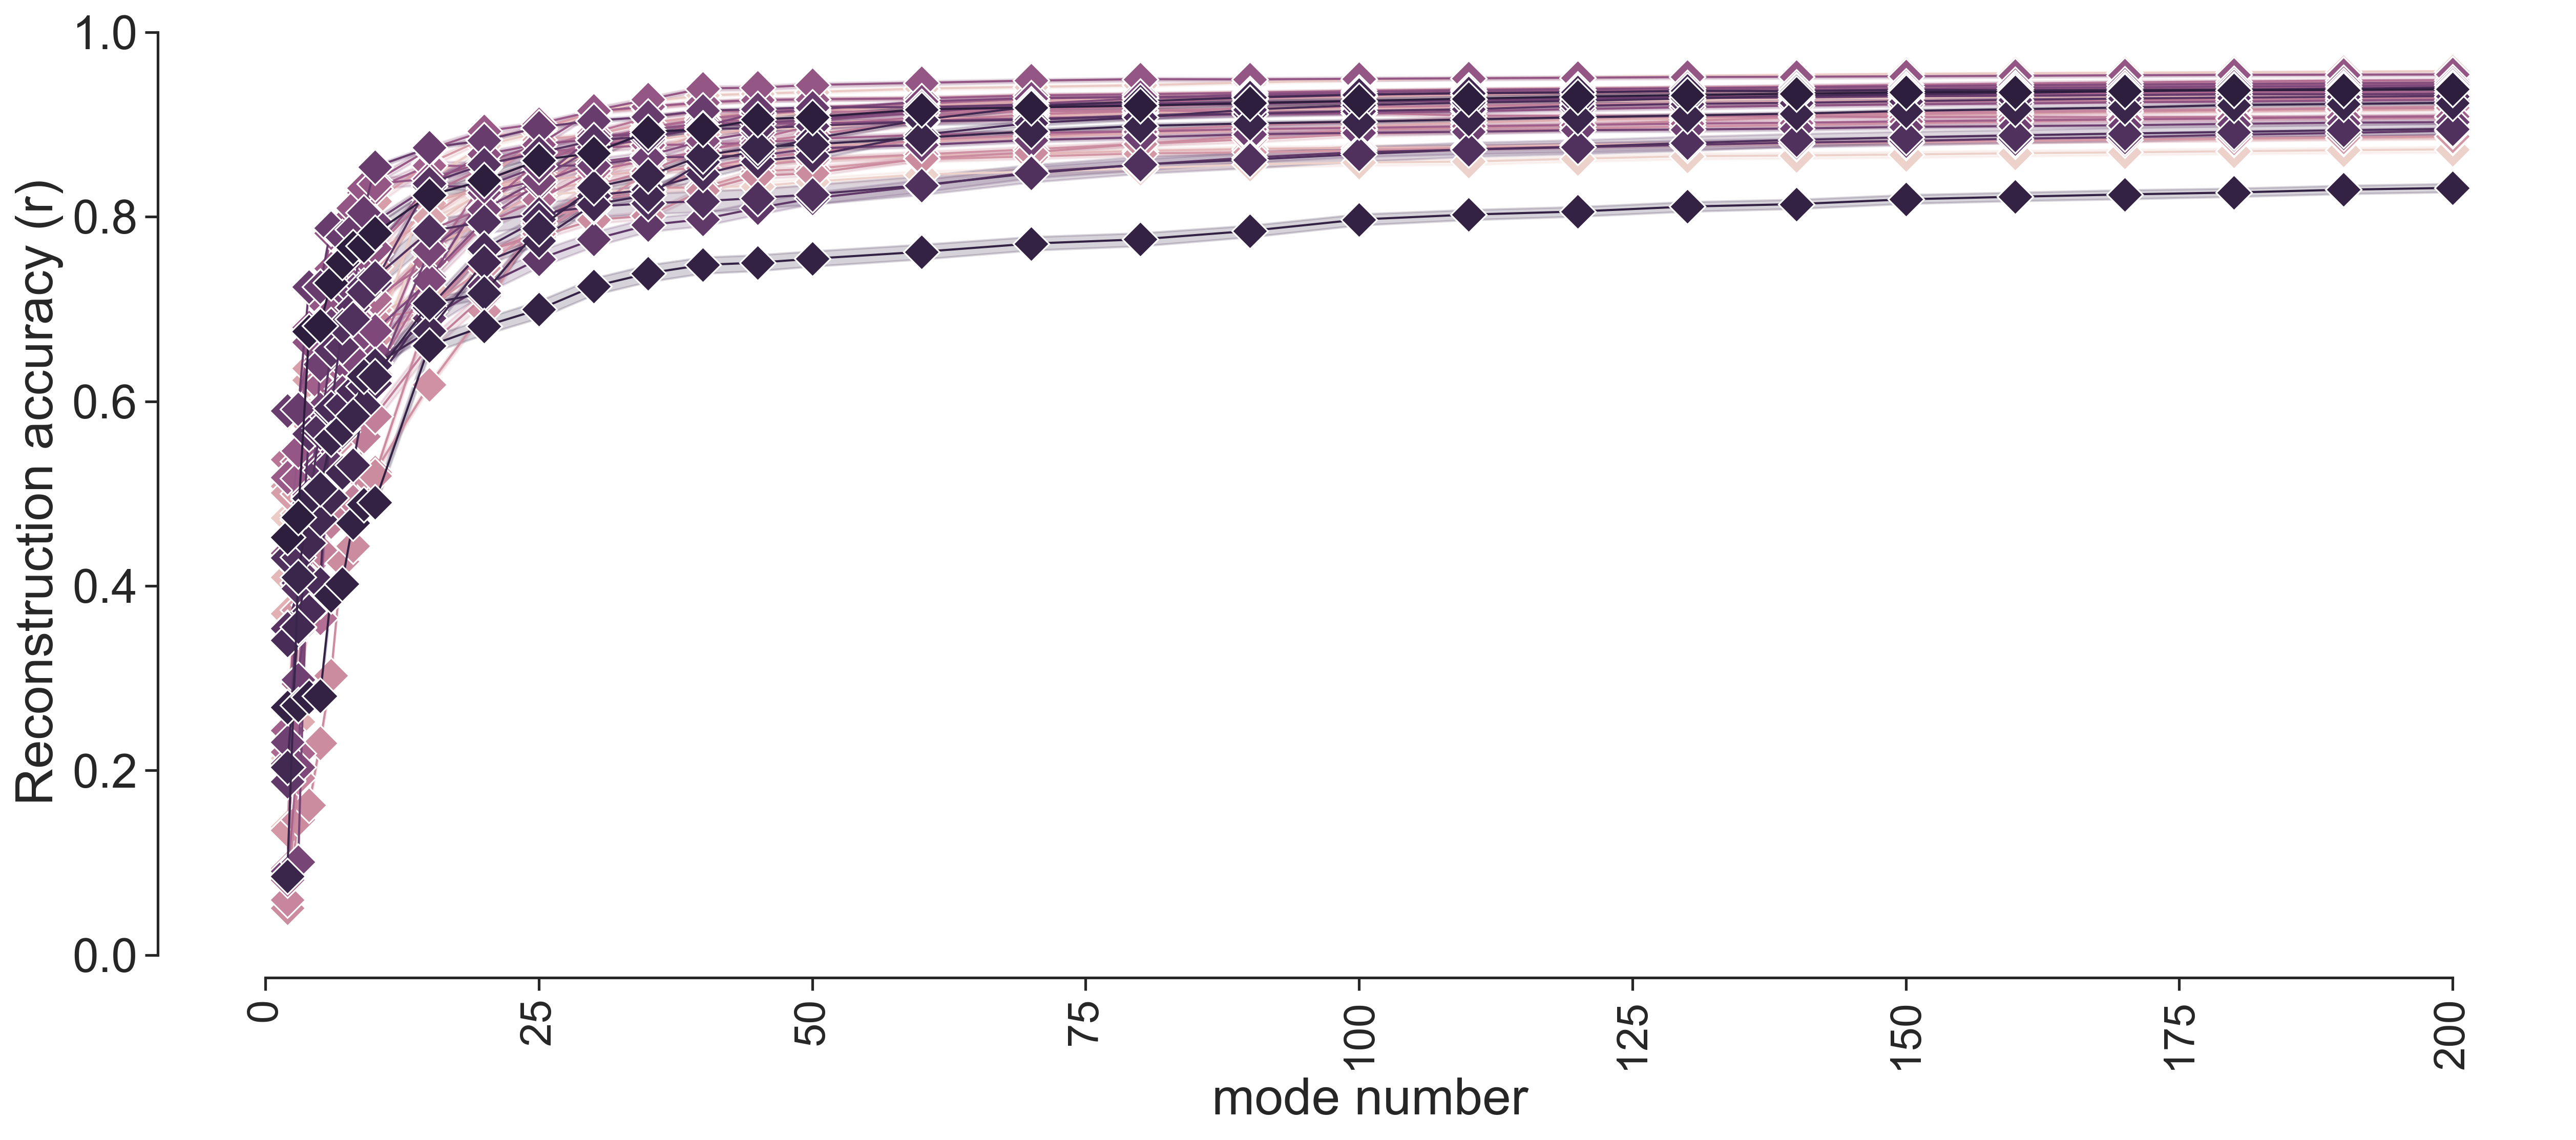

In [7]:
import os

import numpy as np
import pandas as pd

import scipy.io as sio
from scipy import stats

from sklearn.linear_model import LinearRegression
from sklearn.metrics import auc

import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['pdf.fonttype'] = 42
# matplotlib.rcParams['text.usetex'] = True
matplotlib.rcParams['ps.usedistiller'] = 'xpdf'
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.lines import Line2D
from matplotlib.colors import (ListedColormap, Normalize)
from matplotlib.ticker import (MultipleLocator, FormatStrFormatter, AutoMinorLocator)
import matplotlib.patches as mpatches

import seaborn as sns
from matplotlib import font_manager
font_manager.fontManager.addfont("/n02dat01/users/lchai/anaconda3/envs/Nm/lib/python3.8/site-packages/matplotlib/mpl-data/fonts/ttf/arial.ttf")
plt.rcParams["font.sans-serif"] = "Arial" 

FIG_DIR = './' # 'C:/Users/User/Desktop/'
FIG_EXT = '.png'
def lineplot(x, y, df, palette=None, title=None, hue=None, hue_order=None, \
             err_style='band', markers=True, marker='D', markersize=12, \
             linewidth=1, sort=False, xlim=None, x_major_loc=None, ylim=None, \
             y_major_loc=None, legend=True, figsize=(15,5), fig_name=None, \
             **kwargs):

     sns.set(style="ticks", font_scale=2.0)

     fig = plt.figure(figsize=figsize, dpi=300)
     ax = plt.subplot(111)

     sns.lineplot(x=x, y=y,
                  data=df,
                  palette=palette,
                  hue=hue,
                  hue_order=hue_order,
                  err_style=err_style, #'band' 'bars'
                  markers=markers,
                  marker=marker,
                  markersize=markersize,
                  linewidth=linewidth,
                  sort=sort,
                  ax=ax,
                  **kwargs
                  )

     if legend: ax.legend(fontsize=20, frameon=False, ncol=1, loc='lower center')
     else: ax.get_legend().remove()

     if title is not None: ax.set_title(title)

     if xlim is not None: ax.set_ylim(xlim)
     if x_major_loc is not None: ax.xaxis.set_major_locator(MultipleLocator(x_major_loc))

     if ylim is not None: ax.set_ylim(ylim)
     if y_major_loc is not None: ax.yaxis.set_major_locator(MultipleLocator(y_major_loc))

     sns.despine(offset=10, trim=True)

     if fig_name is not None: fig.savefig(fname=os.path.join(FIG_DIR, fig_name + FIG_EXT), transparent=True, bbox_inches='tight', dpi=300)


# x_list = list(corr_df.columns)
# x_list = list(np.arange(5,200,5))
x_list = [1,2,3,4,5,6,7,8,9,10,15,20,25,30,35,40,45,50,60,70,80,90,100,110,120,130,140,150,160,170,180,190,200]
# read the sublist
# list_path = '/n02dat01/users/dyli/deve_indi_pred/deve_indi_pred_code/sub_list/sub_image_nodc_random50.txt'
# list_path = '/n02dat01/users/dyli/deve_indi_pred/deve_indi_pred_code/sub_list/sub_image_nodc_v3.txt'
list_path = '/n02dat01/users/dyli/Grad_data/support_data/HCP_U100_list.txt'
with open( list_path, 'r' ) as f:
    namelist = [ str( line.strip()) for line in f.readlines() ]

pearsonr = np.load(f'/n01dat01/dyli/multi/results_data/diff_mode_num/HCP_U100_diff_mode_corr_ForAZ.npy')
print(pearsonr.shape) # (647, 40, 36)
# assert ~np.isnan(pearsonr).any()
# assert pearsonr.shape[2] == len(namelist)

df = pd.DataFrame(columns=['sub_name', 'mode number', 'exp_name', 'fiber name', 'dataset_name', 'Reconstruction accuracy (r)'])
for ii in range(len(x_list)):
    # for sub in range(len(namelist)):
    for sub in range(90):
        for fi in range(36):
            #add row to end of DataFrame
            df.loc[len(df.index)] = [namelist[sub], x_list[ii], 'U100', fi, 'HCP', pearsonr[sub, ii, fi]]

lineplot(x='mode number', 
        y='Reconstruction accuracy (r)', 
        df=df, 
        # palette=['#4371c1','#e77b33', '#71ab4e'], 
        hue='fiber name',
        # ylim=[0.7,1],
        fig_name='Reconstruction accuracy HCP ForAZ',
        legend=False,
        figsize=(20,8))
plt.xticks(fontproperties='Arial', fontsize=20, rotation=90)
plt.show()
plt.close()

(100, 32, 36)


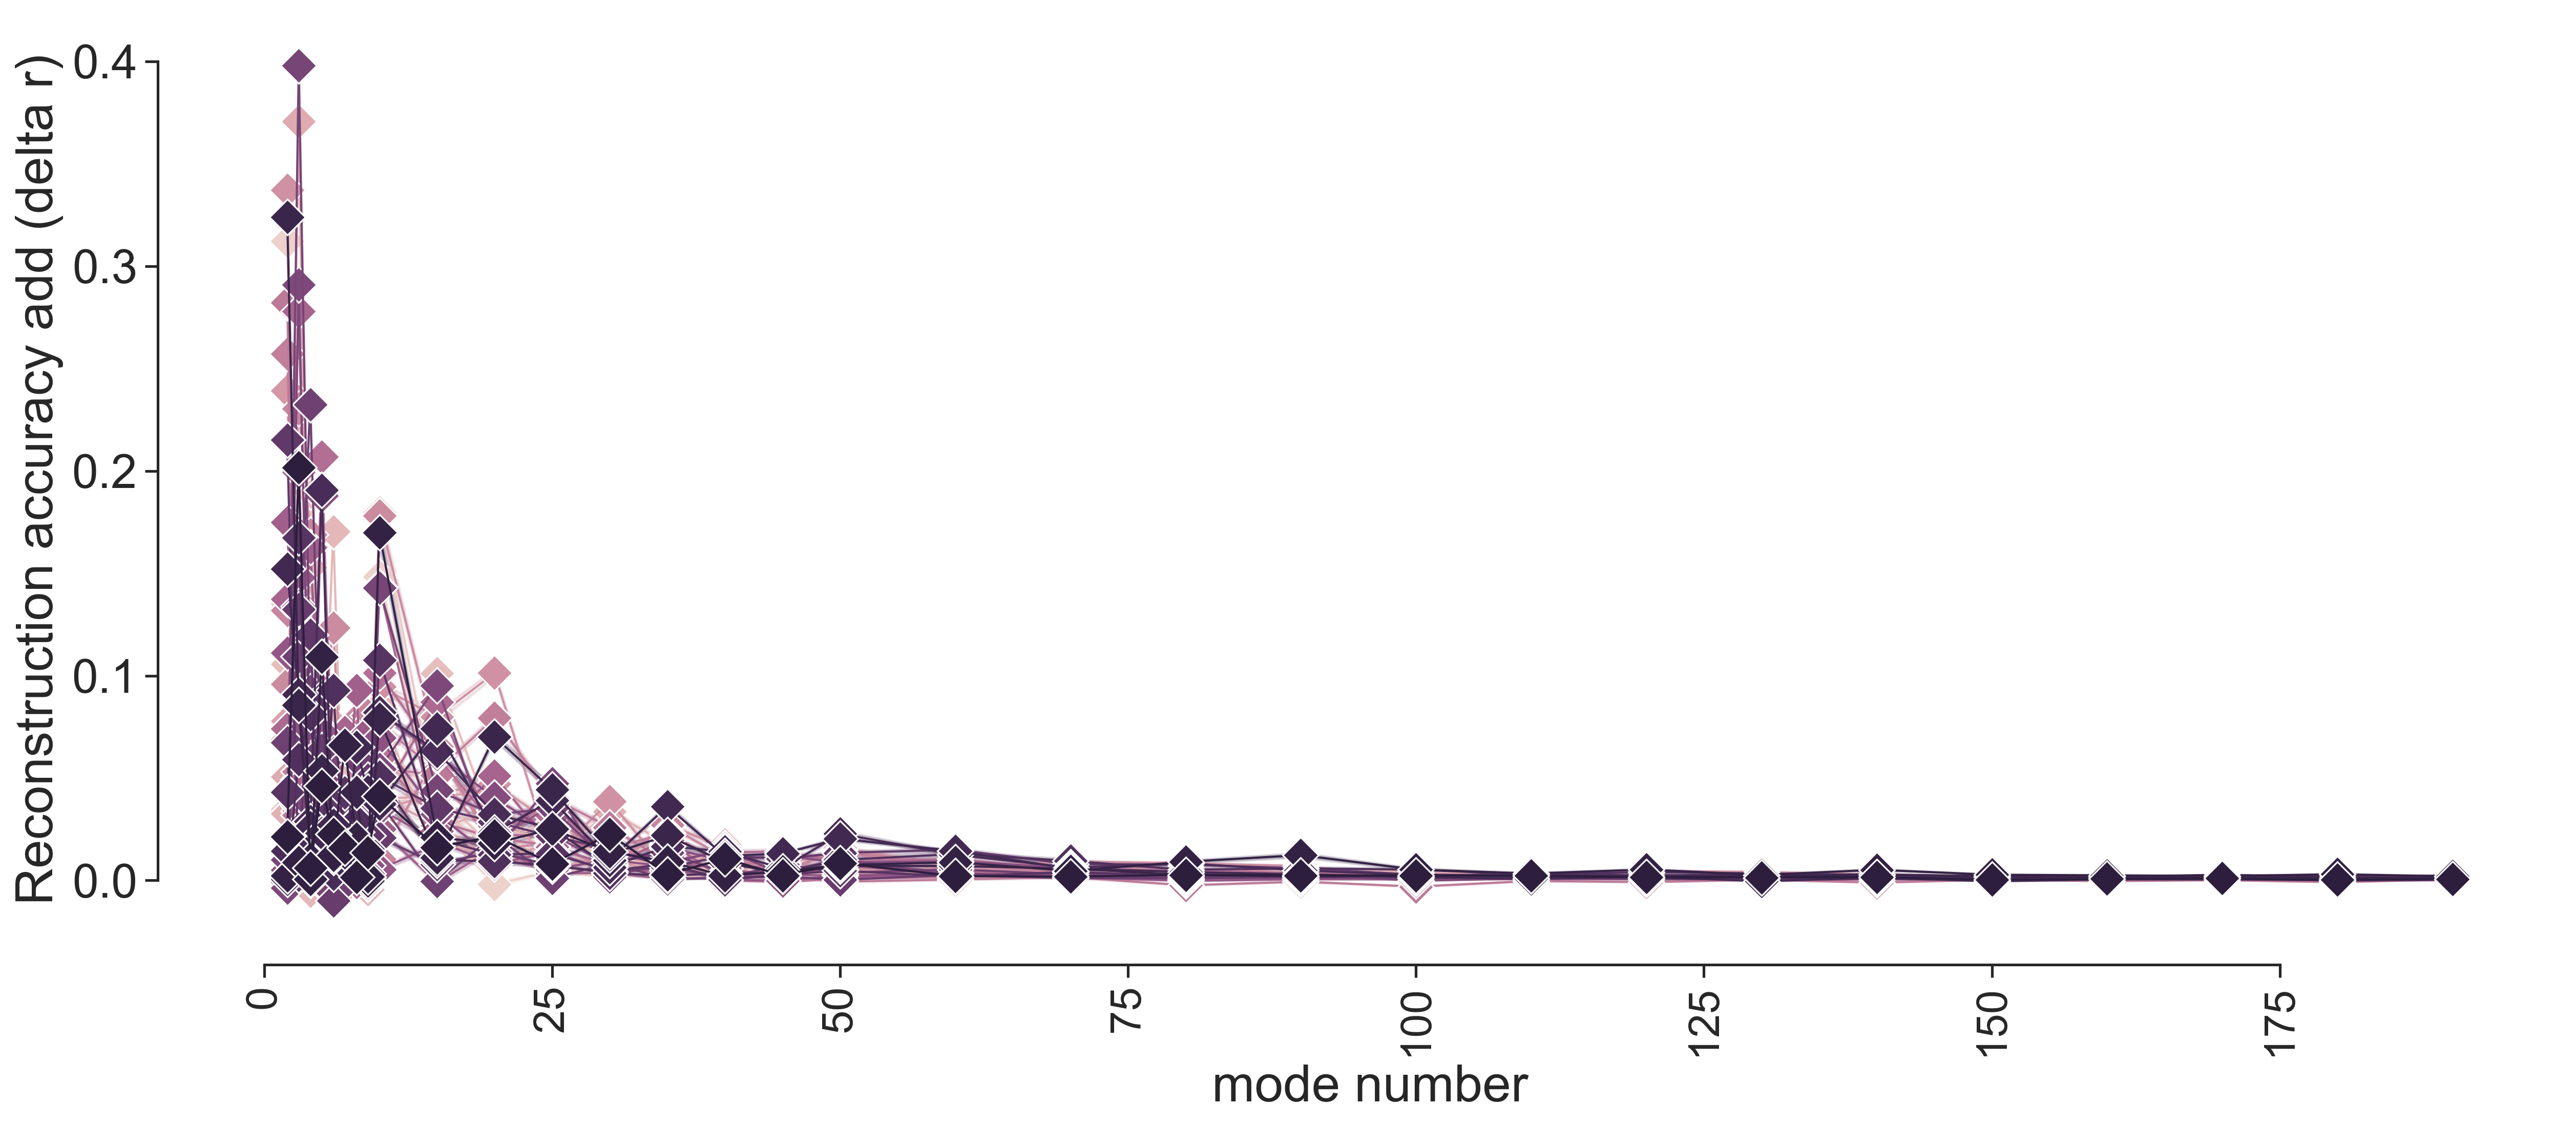

In [13]:
import os

import numpy as np
import pandas as pd

import scipy.io as sio
from scipy import stats

from sklearn.linear_model import LinearRegression
from sklearn.metrics import auc

import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['pdf.fonttype'] = 42
# matplotlib.rcParams['text.usetex'] = True
matplotlib.rcParams['ps.usedistiller'] = 'xpdf'
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.lines import Line2D
from matplotlib.colors import (ListedColormap, Normalize)
from matplotlib.ticker import (MultipleLocator, FormatStrFormatter, AutoMinorLocator)
import matplotlib.patches as mpatches

import seaborn as sns
from matplotlib import font_manager
font_manager.fontManager.addfont("/n02dat01/users/lchai/anaconda3/envs/Nm/lib/python3.8/site-packages/matplotlib/mpl-data/fonts/ttf/arial.ttf")
plt.rcParams["font.sans-serif"] = "Arial" 

FIG_DIR = './' # 'C:/Users/User/Desktop/'
FIG_EXT = '.png'
def lineplot(x, y, df, palette=None, title=None, hue=None, hue_order=None, \
             err_style='band', markers=True, marker='D', markersize=12, \
             linewidth=1, sort=False, xlim=None, x_major_loc=None, ylim=None, \
             y_major_loc=None, legend=True, figsize=(15,5), fig_name=None, \
             **kwargs):

     sns.set(style="ticks", font_scale=2.0)

     fig = plt.figure(figsize=figsize, dpi=300)
     ax = plt.subplot(111)

     sns.lineplot(x=x, y=y,
                  data=df,
                  palette=palette,
                  hue=hue,
                  hue_order=hue_order,
                  err_style=err_style, #'band' 'bars'
                  markers=markers,
                  marker=marker,
                  markersize=markersize,
                  linewidth=linewidth,
                  sort=sort,
                  ax=ax,
                  **kwargs
                  )

     if legend: ax.legend(fontsize=20, frameon=False, ncol=1, loc='lower center')
     else: ax.get_legend().remove()

     if title is not None: ax.set_title(title)

     if xlim is not None: ax.set_ylim(xlim)
     if x_major_loc is not None: ax.xaxis.set_major_locator(MultipleLocator(x_major_loc))

     if ylim is not None: ax.set_ylim(ylim)
     if y_major_loc is not None: ax.yaxis.set_major_locator(MultipleLocator(y_major_loc))

     sns.despine(offset=10, trim=True)

     if fig_name is not None: fig.savefig(fname=os.path.join(FIG_DIR, fig_name + FIG_EXT), transparent=True, bbox_inches='tight', dpi=300)


# x_list = list(corr_df.columns)
# x_list = list(np.arange(5,200,5))
x_list = [1,2,3,4,5,6,7,8,9,10,15,20,25,30,35,40,45,50,60,70,80,90,100,110,120,130,140,150,160,170,180,190]
# read the sublist
# list_path = '/n02dat01/users/dyli/deve_indi_pred/deve_indi_pred_code/sub_list/sub_image_nodc_random50.txt'
# list_path = '/n02dat01/users/dyli/deve_indi_pred/deve_indi_pred_code/sub_list/sub_image_nodc_v3.txt'
list_path = '/n02dat01/users/dyli/Grad_data/support_data/HCP_U100_list.txt'
with open( list_path, 'r' ) as f:
    namelist = [ str( line.strip()) for line in f.readlines() ]

pearsonr = diff.copy()
print(pearsonr.shape) # (647, 40, 36)
# assert ~np.isnan(pearsonr).any()
# assert pearsonr.shape[2] == len(namelist)

df = pd.DataFrame(columns=['sub_name', 'mode number', 'exp_name', 'fiber name', 'dataset_name', 'Reconstruction accuracy add (delta r)'])
for ii in range(len(x_list)):
    # for sub in range(len(namelist)):
    for sub in range(90):
        for fi in range(36):
            #add row to end of DataFrame
            df.loc[len(df.index)] = [namelist[sub], x_list[ii], 'U100', fi, 'HCP', pearsonr[sub, ii, fi]]

lineplot(x='mode number', 
        y='Reconstruction accuracy add (delta r)', 
        df=df, 
        # palette=['#4371c1','#e77b33', '#71ab4e'], 
        hue='fiber name',
        # ylim=[0.7,1],
        fig_name='Reconstruction accuracy adding HCP ForAZ',
        legend=False,
        figsize=(20,8))
plt.xticks(fontproperties='Arial', fontsize=20, rotation=90)
plt.show()
plt.close()

# calculate the 500 mode results: HCP

In [26]:
# check the results
# read the sublist
# list_path = '/n02dat01/users/dyli/multi/scripts/data_preprocess/sub_list/HCP_retest.txt'
list_path = '/n02dat01/users/dyli/Grad_data/support_data/HCP_U100_list.txt'
# list_path = '/n02dat01/users/dyli/HCP1200/scripts/HCP_968.txt'
with open( list_path, 'r' ) as f:
    namelist = [ str( line.strip()) for line in f.readlines() ]
print(f'the sub number is {len(namelist)}')

# train a GLM for each sub
for sub in namelist:
    if not os.path.exists(f'/n01dat01/dyli/multi/HCP_1200/{sub}/FP_{sub}_predict_by_500_group_whitemode_deve-mode_thr05_para_L.npy'):
        print(sub)

the sub number is 100


In [30]:
# read the sublist
list_path = '/n02dat01/users/dyli/Grad_data/support_data/HCP_U100_list.txt'
with open( list_path, 'r' ) as f:
    namelist = [ str( line.strip()) for line in f.readlines() ]
print(f'the sub num is {len(namelist)}')

# read the group MODE
x = np.loadtxt(f'/n01dat01/dyli/multi/support_code/BrainEigenmodes/data/template_eigenmodes/fsLR_32k_white-lh_emode_1000.txt')[:, 0:500] # (32492, 200)
x = x[select_ind_L,:]

# train a GLM for each sub
# corr_re = np.zeros((len(namelist), len(list(np.arange(5,205,5))),36))
corr_re = np.zeros((len(namelist), len(list([i*10+200 for i in range(31)])),36))
for sub_i, sub in tqdm(enumerate(namelist)):
    # read the fingerprint
    if os.path.exists(f'/n04dat01/atlas_group/lma/HCP_S1200_individual_MSM_atlas/{sub}/{sub}_L_probtrackx_omatrix2/finger_print_fiber_MSMALL.npz'):
        _ = sps.load_npz(f'/n04dat01/atlas_group/lma/HCP_S1200_individual_MSM_atlas/{sub}/{sub}_L_probtrackx_omatrix2/finger_print_fiber_MSMALL.npz')
    else:
        _ = sps.load_npz(f'/n04dat01/atlas_group/lma/HCP_S1200_individual_MSM_atlas/{sub}/{sub}_L_probtrackx_omatrix2/finger_print_fiber.npz')
    _ = _.toarray()

    # check the all-zero row
    for ii in range(_.shape[0]):
        if len(np.unique(_[ii,:])) == 1: _[ii,:]=_[ii-1,:]
    for ii in range(_.shape[0]):
        if len(np.unique(_[ii,:])) == 1: sys.exit()

    # normalization
    fingerprint = np.array([_[:,i]/np.sum(_, axis=1) for i in range(_.shape[1])]).T

    # choose the left fibers and the cc fibers
    fingerprint = fingerprint[:, np.array(list(l_idx) + list(m_idx))]
    assert fingerprint.shape[0]==29696 and fingerprint.shape[1]==int(len(l_idx)+len(m_idx))

    # thr
    fingerprint[fingerprint<0.05] =0

    for ff in range(36):
        # read the parameter
        para = np.load(f'/n01dat01/dyli/multi/HCP_1200/{sub}/FP_{sub}_predict_by_500_group_whitemode_deve-mode_thr05_para_L.npy')[:, new_fiber_idx] # (200, 36)
        # for mode_i, mode_num in enumerate(list(np.arange(5,205,5))):
        for mode_i, mode_num in enumerate(list([i*10+200 for i in range(31)])):
            result = para[0:mode_num, ff]
            corr_re[sub_i,mode_i,ff] = np.corrcoef(np.squeeze(fingerprint[:,ff]), np.squeeze(np.dot(x[:, 0:mode_num],result.T)))[0,1]

np.save(f'/n01dat01/dyli/multi/results_data/diff_mode_num/HCP_U100_diff_mode500_corr_ForAZ.npy', corr_re)

the sub num is 100


100it [1:16:32, 45.92s/it]


In [5]:
# corr_re = np.load(f'/n01dat01/dyli/multi/results_data/diff_mode_num/HCP_U100_diff_mode_corr_100_new.npy')
corr_re = np.load(f'/n01dat01/dyli/multi/results_data/diff_mode_num/HCP_U100_diff_mode500_corr_ForAZ.npy')
print(corr_re.shape)

(100, 31, 36)


In [6]:
np.min(np.min(corr_re, axis=0), axis=1)

array([0.7553881 , 0.75871221, 0.75922199, 0.76015673, 0.76053488,
       0.76170343, 0.76211934, 0.76297156, 0.7637964 , 0.76456806,
       0.76525351, 0.76547724, 0.76754069, 0.76795381, 0.76821845,
       0.7696663 , 0.7715713 , 0.77328601, 0.77477496, 0.77575009,
       0.77626708, 0.77702659, 0.77781372, 0.77916856, 0.78069927,
       0.78206482, 0.78235604, 0.78309499, 0.78382132, 0.78431866,
       0.7847387 ])

In [12]:
diff = np.zeros((100, 30, 36))
for i,n in enumerate(list([i*10+200 for i in range(31)])[0:-1]):
    diff[:, i, :] = corr_re[:, i+1, :] - corr_re[:, i, :]

In [13]:
np.mean(np.mean(diff, axis=0),axis=1)

array([0.00077529, 0.00060602, 0.00064873, 0.00052794, 0.00059289,
       0.00054759, 0.00046632, 0.00046448, 0.00042931, 0.00042678,
       0.00041532, 0.00030957, 0.00034675, 0.00033002, 0.00032841,
       0.00033607, 0.00026384, 0.00027993, 0.00027148, 0.00026254,
       0.00021377, 0.00021137, 0.0002399 , 0.00021856, 0.00020766,
       0.00021188, 0.0002292 , 0.00021735, 0.00019064, 0.00020263])